최종 파라미터: a=219478.951453, b=-424745.389627
최종 MSE: 57328884063.1546325684 (정답은 a=2, b=3)


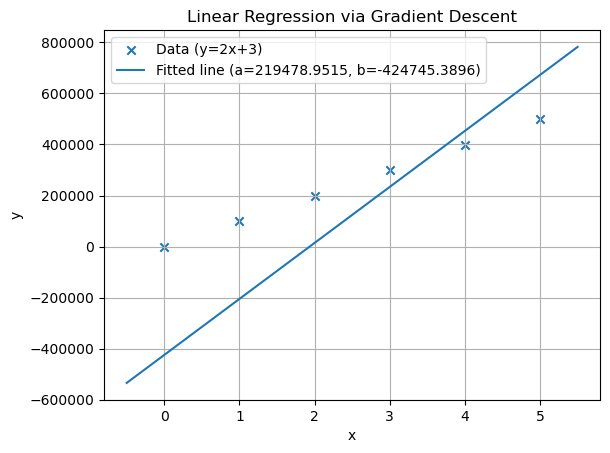

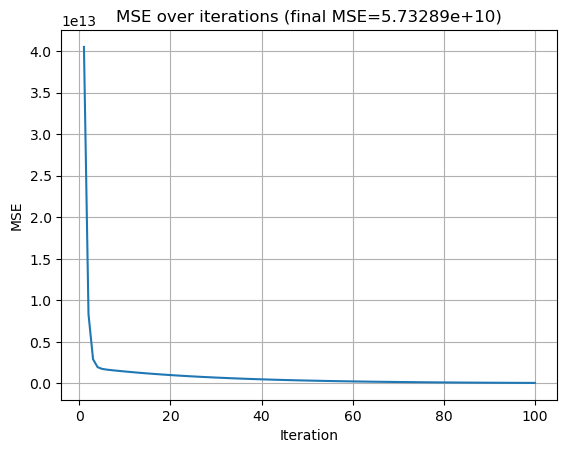

In [63]:
# -*- coding: utf-8 -*-
# Linear Regression from scratch with MSE + manual partial derivatives (gradient descent)

import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 만들기: y = 2x + 3 을 정확히 만족하는 6개 점
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([100000*i + -777 for i in x])

# 2) MSE와 그라디언트(편미분) 직접 구현
def mse(a, b, x, y):
    """
    MSE(a,b) = (1/n) * sum_i (y_i - (a*x_i + b))^2
    """
    y_hat = a * x + b
    return np.mean((y - y_hat) ** 2)

def grad(a, b, x, y):
    """
    d(MSE)/da = -(2/n) * sum_i x_i * (y_i - y_hat_i)
    d(MSE)/db = -(2/n) * sum_i (y_i - y_hat_i)
    """
    n = len(x)
    y_hat = a * x + b
    residual = y - y_hat
    d_a = (-2.0 / n) * np.sum(x * residual)
    d_b = (-2.0 / n) * np.sum(residual)
    return d_a, d_b

# 3) 경사하강법으로 학습
rng = np.random.default_rng(42)
a = rng.uniform(-10000000, 10000000)   # 기울기 초기값 (무작위)
b = rng.uniform(-10000000, 10000000)   # 절편 초기값 (무작위)

lr = 0.03     # 학습률
iters = 100   # 반복 횟수

history_mse = []
history_a = []
history_b = []

for _ in range(iters):
    d_a, d_b = grad(a, b, x, y)
    a -= lr * d_a
    b -= lr * d_b
    history_mse.append(mse(a, b, x, y))
    history_a.append(a)
    history_b.append(b)

print(f"최종 파라미터: a={a:.6f}, b={b:.6f}")
print(f"최종 MSE: {history_mse[-1]:.10f} (정답은 a=2, b=3)")

# 4) 결과 시각화
xx = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)
yy = a * xx + b

plt.figure()
plt.scatter(x, y, label="Data (y=2x+3)", marker="x")
plt.plot(xx, yy, label=f"Fitted line (a={a:.4f}, b={b:.4f})")
plt.title("Linear Regression via Gradient Descent")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(range(1, iters + 1), history_mse)
plt.title(f"MSE over iterations (final MSE={history_mse[-1]:.6g})")
plt.xlabel("Iteration"); plt.ylabel("MSE"); plt.grid(True)
plt.show()

In [28]:
# 문 1) 기울기 100이고, y절편은 b가 -20이 되도록 y데이터를 수정하고 
# 반복했을 때, 100과 -20을 찾는 프로그램
#  y = 100x - 20

import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 만들기: y = 2x + 3 을 정확히 만족하는 6개 점
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([100*i + -20 for i in x])
print(y)

# 2) MSE와 그라디언트(편미분) 직접 구현
def mse(a, b, x, y):
    y_hat = a * x + b
    return np.mean((y - y_hat) ** 2)

def grad(a, b, x, y):
    n = len(x)
    y_hat = a * x + b
    e = y - y_hat
    d_a = (-2.0 / n) * np.sum(x * e)
    d_b = (-2.0 / n) * np.sum(e)
    return d_a, d_b

# 3) 경사하강법으로 학습
rng = np.random.default_rng(42)
a = -10000
b = 10000

lr = 0.05    # 학습률
iters = 1000   # 반복 횟수

history_mse = []
history_a = []
history_b = []

for j in range(iters):
    d_a, d_b = grad(a, b, x, y)
    a -= lr * d_a
    b -= lr * d_b
    cost = mse(a, b, x, y)
    history_mse.append(cost)
    history_a.append(a)
    history_b.append(b)
    if j%20==0:
        print(a,b,cost)

print("a" , a , ",b" , b)

[-20.  80. 180. 280. 380. 480.]
-3246.666666666667 11523.0 42756278.629629634
-1689.3040213187676 6329.305339970998 12857571.819715604
-882.1368713557481 3465.0907434307533 3873777.8732611216
-439.0882838152483 1892.942729889597 1167106.4507185747
-195.90191166094942 1030.001321984279 351630.2462025786
-62.41855731854746 556.3386216127667 105940.49066249258
10.849552767794222 296.3483700523161 31918.15176031171
51.065922682009294 153.641479994372 9616.421496856228
73.14041603486135 75.31063355771236 2897.2718439225646
85.25695608620181 32.31536191390996 872.9010204399488
91.90764294315606 8.715548202983436 262.9909212983977
95.55815996219326 -4.238229872999889 79.2348995657272
97.56190405553387 -11.34847101715502 23.8721902573491
98.661745631579 -15.251234275217007 7.1923037803606595
99.26544123144011 -17.39343462252863 2.166924488760093
99.59680566176304 -18.56927389962095 0.6528592066439097
99.77868935564537 -19.21468412340703 0.19669589130149157
99.8785240846416 -19.568945428572523 

In [40]:
import numpy as np

# 데이터 정의
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([100 * i - 20 for i in x])

# 초기값 고정
a = 100
b = 1000

# MSE 함수
def mse(a, b, x, y):
    y_hat = a * x + b
    return np.mean((y - y_hat) ** 2)

# 기울기(편미분) 함수
def grad(a, b, x, y):
    n = len(x)
    y_hat = a * x + b
    e = y - y_hat
    d_a = (-2.0 / n) * np.sum(x * e)
    d_b = (-2.0 / n) * np.sum(e)
    return d_a, d_b

# 경사하강법 학습
lr = 0.05
iters = 400

for j in range(iters):
    d_a, d_b = grad(a, b, x, y)
    print('a와b',a,b)
    a -= lr * d_a
    b -= lr * d_b
    cost = mse(a, b, x, y)
    print(f"iter={j+1}, a={a:.6f}, b={b:.6f}, MSE={cost:.6f}")

print("\n최종 결과:")
print(f"a={a:.6f}, b={b:.6f}, MSE={mse(a,b,x,y):.6f}")

a와b 100 1000
iter=1, a=-155.000000, b=898.000000, MSE=268336.500000
a와b -155.0 898.0
iter=2, a=-150.750000, b=869.950000, MSE=252595.512917
a와b -150.75 869.95
iter=3, a=-143.383333, b=843.642500, MSE=237889.012505
a와b -143.38333333333335 843.6425
iter=4, a=-136.192569, b=818.124083, MSE=224038.765675
a와b -136.19256944444447 818.1240833333334
iter=5, a=-129.213735, b=793.359817, MSE=210994.900509
a와b -129.21373495370372 793.3598173611111
iter=6, a=-122.441099, b=769.327269, MSE=198710.468284
a와b -122.4410989197531 769.327269363426
iter=7, a=-115.868576, b=746.004817, MSE=187141.253700
a와b -115.86857558416926 746.0048171570216
iter=8, a=-109.490252, b=723.371479, MSE=176245.615738
a와b -109.49025225460285 723.3714793373618
iter=9, a=-103.300391, b=701.406894, MSE=165984.337781
a와b -103.30039085555737 701.4068944672764
iter=10, a=-97.293423, b=680.091303, MSE=156320.486460
a와b -97.29342285478222 680.0913027344382
iter=11, a=-91.463944, b=659.405528, MSE=147219.278722
a와b -91.4639442548414 

In [36]:
pwd

'C:\\Users\\Administrator\\math\\0925'

<img src="images/1.jpg" />

<img src="images/2.jpg" />

In [54]:
import numpy as np

# 데이터 정의
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([100 * i - 20 + 0.03 for i in x])

# 초기값
a = 20000000
b = 7800

# Loss 함수: 1/(2n)
def mse(a, b, x, y):
    y_hat = a * x + b
    return np.mean((y - y_hat) ** 2) / 2   # 여기서 1/(2n) 처리가 됨

# Gradient 함수
def grad(a, b, x, y):
    n = len(x)
    y_hat = a * x + b
    e = y - y_hat
    d_a = (-1.0 / n) * np.sum(x * e)
    d_b = (-1.0 / n) * np.sum(e)
    return d_a, d_b

# 경사하강법 학습
lr = 0.05
iters = 4000

for j in range(iters):
    d_a, d_b = grad(a, b, x, y)
    a -= lr * d_a
    b -= lr * d_b
    cost = mse(a, b, x, y)
    print(f"iter={j+1}, a={a:.6f}, b={b:.6f}, MSE={cost:.6f}")

print("\n최종 결과:")
print(f"a={a:.6f}, b={b:.6f}, MSE={mse(a,b,x,y):.6f}")

iter=1, a=10832401.670417, b=-2492578.498500, MSE=473408706840972.812500
iter=2, a=6179166.554205, b=-3721988.280877, MSE=124426423578969.375000
iter=3, a=3812340.422387, b=-4308273.184609, MSE=34830675001946.949219
iter=4, a=2603595.213953, b=-4569390.576677, MSE=11765429532356.306641
iter=5, a=1981497.900059, b=-4666358.948087, MSE=5766554941318.860352
iter=6, a=1656649.568126, b=-4680716.736690, MSE=4147329420813.319824
iter=7, a=1482484.778571, b=-4653750.594371, MSE=3653768654732.159668
iter=8, a=1384774.749772, b=-4606362.160474, MSE=3451215633481.531250
iter=9, a=1325924.929936, b=-4549129.394672, MSE=3325528732076.535156
iter=10, a=1286893.848466, b=-4487402.039680, MSE=3221719184253.395020
iter=11, a=1258036.093296, b=-4423882.167255, MSE=3125619947157.009277
iter=12, a=1234464.825192, b=-4359931.069054, MSE=3033535866062.558105
iter=13, a=1213703.167694, b=-4296231.117250, MSE=2944459440334.854980
iter=14, a=1194494.775907, b=-4233120.955849, MSE=2858074256342.016602
iter=15,